In [1]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from skimage import feature
from scipy import ndimage

In [2]:
# function for extracting histogram of each channel
def extract_histograms(img, bins=32):
    hist = []
     # rgb histograms
    for i in range(3):  
        channel_hist = cv2.calcHist([img], [i], None, [bins], [0, 256])
        channel_hist = cv2.normalize(channel_hist, channel_hist).flatten()
        hist.extend(channel_hist)
    
    #hsv histograms
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    for i in range(3):
        hist_hsv = cv2.calcHist([hsv], [i], None, [bins], [0, 256])
        hist_hsv = cv2.normalize(hist_hsv, hist_hsv).flatten()
        hist.extend(hist_hsv)

    return np.array(hist, dtype=np.float32)

In [3]:
# function for extracting mean, std, skewness
def extract_color_moments(image):
    moments = []
    for i in range(3):
        channel = image[:, :, i]
        mean = np.mean(channel)
        std = np.std(channel)
        skew =  np.cbrt(np.mean((channel - mean)**3))
        moments.extend([mean, std, skew])
    return np.array(moments)

In [4]:
# function for extracting local binary pattern 
def extract_lbp(image, radius=3, n_points=8*3, method='uniform'):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, n_points, radius, method)
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)  
    return hist

In [ ]:
# function for extracting lorb features 
def extract_orb_features(img, n_features=500):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    orb = cv2.ORB_create(nfeatures=n_features)
    
    try:
        _, descriptors = orb.detectAndCompute(gray, None)
        if descriptors is None:
            return np.zeros(32)
        
        if len(descriptors) > 0:
            return np.mean(descriptors.astype(float), axis=0)
    except:
        pass
    
    return np.zeros(32)

In [ ]:
# function for extracting sift features
def extract_sift_features(img, max_features=100):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    sift = cv2.SIFT_create()
    
    try:
        _, descriptors = sift.detectAndCompute(gray, None)
        if descriptors is None:
            return np.zeros(128)
        
        if len(descriptors) > 0:
            return np.mean(descriptors, axis=0)
    except:
        pass
    
    return np.zeros(128)

In [ ]:
# function for extracting hog features
def extract_hog_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # gradients
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    
    # magnitude and direction
    magnitude = np.sqrt(gx**2 + gy**2)
    direction = np.arctan2(gy, gx)
    
    bins = 9
    features = []
    h, w = gray.shape
    cell_h, cell_w = h // 4, w // 4
    
    for i in range(4):
        for j in range(4):
            mag_cell = magnitude[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
            dir_cell = direction[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
            
            hist, _ = np.histogram(dir_cell, bins=bins, range=(-np.pi, np.pi), 
                                   weights=mag_cell)
            features.extend(hist)
    
    return np.array(features)

In [8]:
def extract_all_features(img):
    features = []
    
    features.extend(extract_histograms(img, bins=32))    
    features.extend(extract_color_moments(img))                 
    features.extend(extract_lbp(img))             
    features.extend(extract_sift_features(img))                 
    features.extend(extract_orb_features(img))            
    features.extend(extract_hog_features(img))           
    
    return np.array(features, dtype=np.float32)

In [9]:
dataset_path = '/kaggle/input/custopn-flowers/custom_flowers_ds'

labels = []
features = []
for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        flower = cv2.imread(os.path.join(dirname, filename))
        flower = cv2.resize(flower, (128,128))
        flower = cv2.cvtColor(flower, cv2.COLOR_BGR2RGB)
        
        feat = extract_all_features(flower)
        features.append(feat)
        
        labels.append(os.path.basename(dirname))

df = pd.DataFrame(np.array(features))

labels = np.unique(labels, return_inverse=True)[1]
df['labels'] = np.array(labels)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2960 entries, 0 to 2959
Columns: 532 entries, 0 to labels
dtypes: float32(531), int64(1)
memory usage: 6.0 MB


,0,1,2,3,4,5,6,7,8,9,...,522,523,524,525,526,527,528,529,530,labels
0,0.000000,0.000353,0.008116,0.014644,0.008116,0.008998,0.013233,0.013056,0.118564,0.360634,...,582.186768,1677.549072,1168.147583,49.497475,42.649109,15.730447,23.486834,127.992317,611.863892,1
1,0.032126,0.018088,0.027536,0.044004,0.065601,0.109066,0.153880,0.194104,0.216511,0.247827,...,16973.554688,10427.766602,7019.931641,4774.602539,9237.020508,4567.008301,4262.620117,7360.239258,12232.625977,1
2,0.004637,0.004981,0.008588,0.009446,0.014084,0.023186,0.034350,0.070418,0.118680,0.197514,...,10749.603516,1301.426758,992.809937,2054.890625,20428.607422,3213.907715,2182.251953,3024.167969,17447.410156,1
3,0.000000,0.000177,0.007072,0.014322,0.057640,0.192193,0.387039,0.568270,0.618131,0.237987,...,6066.630371,1037.855713,872.886719,1681.096191,3796.923828,2691.718994,1064.845337,866.083191,7765.541992,1
4,0.006214,0.011184,0.012427,0.012427,0.012427,0.011599,0.017398,0.013256,0.013670,0.013877,...,2505.600098,2084.986084,558.982849,899.851807,1636.813232,1169.959717,920.667480,1116.988159,2807.572754,1


In [10]:
X = df.iloc[:, :-1].values 
y = df.iloc[:, -1].values

print(X.shape)
print(y.shape)

(2960, 531)
(2960,)


In [11]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, classification_report, accuracy_score, confusion_matrix

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (2368, 531)
Test size: (592, 531)


In [13]:
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('svm', SVC(kernel='rbf',gamma='scale',class_weight='balanced',probability=True))
])

In [14]:
param_grid = {
            'pca__n_components': [100, 200, 300, 400, 500],  
            'svm__C': [0.1, 1, 10, 100, 500, 1000],
    }

In [15]:
num_folds = 5
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [16]:
grid = GridSearchCV(clf, param_grid, cv=skf, refit = True, verbose = 3, error_score='raise') 

grid.fit(X_train, y_train)
print(f'The best params are: {grid.best_params_}') 

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END .pca__n_components=100, svm__C=0.1;, score=0.658 total time=   2.1s
[CV 2/5] END .pca__n_components=100, svm__C=0.1;, score=0.660 total time=   2.2s
[CV 3/5] END .pca__n_components=100, svm__C=0.1;, score=0.627 total time=   2.1s
[CV 4/5] END .pca__n_components=100, svm__C=0.1;, score=0.645 total time=   2.1s
[CV 5/5] END .pca__n_components=100, svm__C=0.1;, score=0.603 total time=   2.1s
[CV 1/5] END ...pca__n_components=100, svm__C=1;, score=0.753 total time=   1.7s
[CV 2/5] END ...pca__n_components=100, svm__C=1;, score=0.757 total time=   1.7s
[CV 3/5] END ...pca__n_components=100, svm__C=1;, score=0.747 total time=   1.6s
[CV 4/5] END ...pca__n_components=100, svm__C=1;, score=0.770 total time=   1.6s
[CV 5/5] END ...pca__n_components=100, svm__C=1;, score=0.740 total time=   1.6s
[CV 1/5] END ..pca__n_components=100, svm__C=10;, score=0.757 total time=   2.0s
[CV 2/5] END ..pca__n_components=100, svm__C=10

In [17]:
grid_predictions = grid.predict(X_test) 

print(classification_report(y_test, grid_predictions))

              precision    recall  f1-score   support

           0       0.71      0.75      0.73       100
           1       0.79      0.70      0.74       133
           2       0.71      0.72      0.71       110
           3       0.77      0.91      0.84       112
           4       0.81      0.74      0.78       137

    accuracy                           0.76       592
   macro avg       0.76      0.76      0.76       592
weighted avg       0.76      0.76      0.76       592



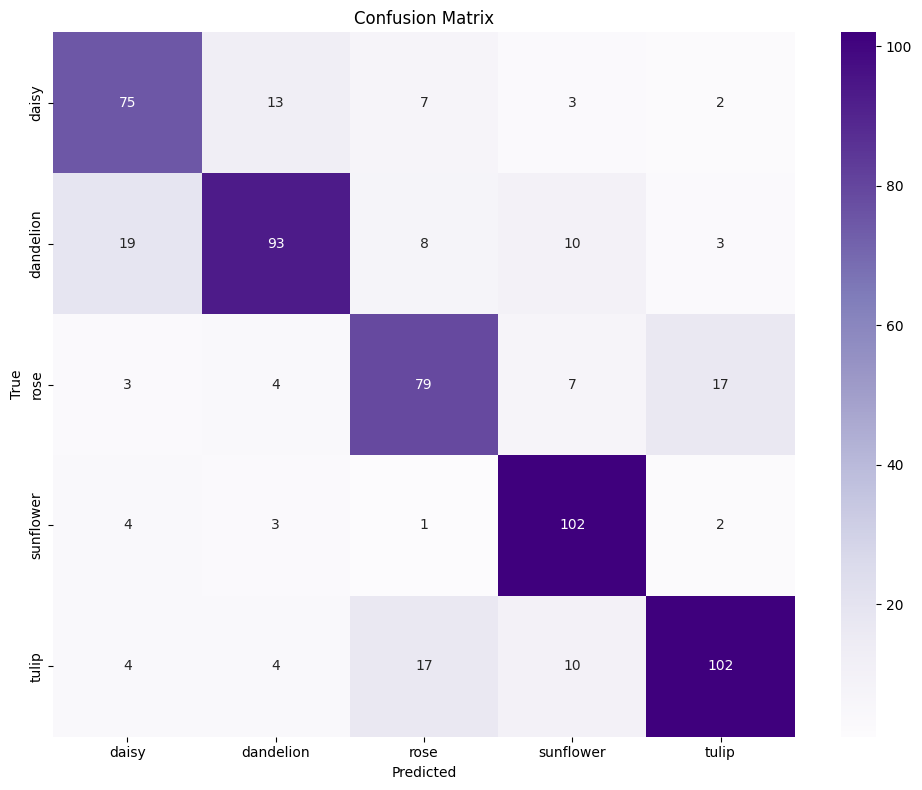

In [18]:
import seaborn as sns
cm = confusion_matrix(y_test, grid_predictions)

class_names = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=True, xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [25]:
results = pd.DataFrame(grid.cv_results_)
top5 = results.sort_values(by='mean_test_score', ascending=False).head(15)

In [26]:
top5[[
    'rank_test_score',
    'param_pca__n_components',
    'param_svm__C',
    'mean_test_score',
]]

,rank_test_score,param_pca__n_components,param_svm__C,mean_test_score
29,1,500,1000,0.771964
28,1,500,500,0.771964
27,1,500,100,0.771964
26,1,500,10,0.771964
17,5,300,1000,0.770277
16,6,300,500,0.770276
22,7,400,500,0.769852
21,8,400,100,0.769431
15,9,300,100,0.769010
23,10,400,1000,0.769008


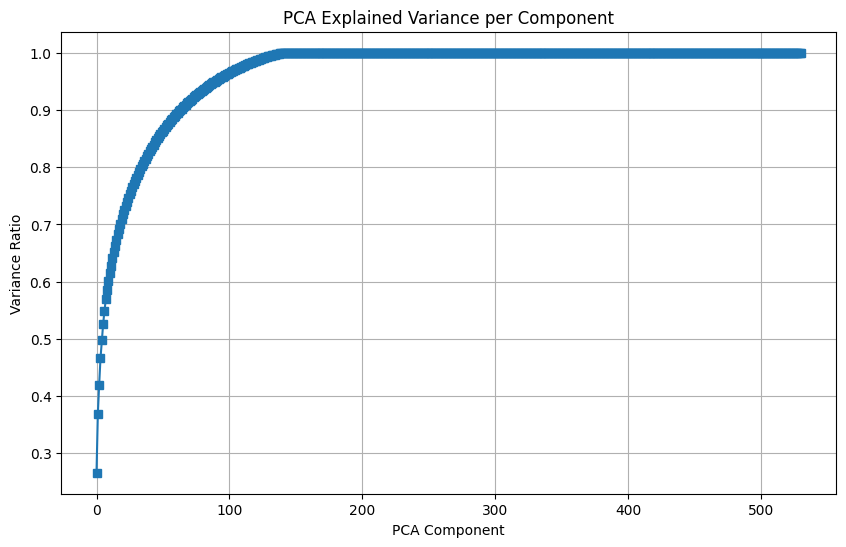

In [24]:
pca = PCA().fit(X)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10,6))
plt.plot(cumulative, marker='s', label='Cumulative variance')
plt.xlabel('PCA Component')
plt.ylabel('Variance Ratio')
plt.title('PCA Explained Variance per Component')
plt.grid(True)
plt.show()